<a href="https://colab.research.google.com/github/Yatha04/ML-tinkering/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [5]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nColumn names:")
print(X.columns.tolist())

Feature matrix shape: (4424, 36)
Target shape: (4424, 1)

First 5 rows of X:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0  

In [7]:
print("Target column name:", y.columns.tolist())
print("\nClass distribution:")
print(y.value_counts())
print("\nIn percentages:")
print(y.value_counts(normalize=True).round(3) * 100)

Target column name: ['Target']

Class distribution:
Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In percentages:
Target  
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


In [9]:
print("\nMissing values per column:")
print(X.isnull().sum().sum(), "total missing values")

print("\nFeature value ranges (first look):")
print(X.describe().T[['min', 'max', 'mean', 'std']].head(10))


Missing values per column:
0 total missing values

Feature value ranges (first look):
                                 min     max         mean          std
Marital Status                   1.0     6.0     1.178571     0.605747
Application mode                 1.0    57.0    18.669078    17.484682
Application order                0.0     9.0     1.727848     1.313793
Course                          33.0  9991.0  8856.642631  2063.566416
Daytime/evening attendance       0.0     1.0     0.890823     0.311897
Previous qualification           1.0    43.0     4.577758    10.216592
Previous qualification (grade)  95.0   190.0   132.613314    13.188332
Nacionality                      1.0   109.0     1.873192     6.914514
Mother's qualification           1.0    44.0    19.561935    15.603186
Father's qualification           1.0    44.0    22.275316    15.343108


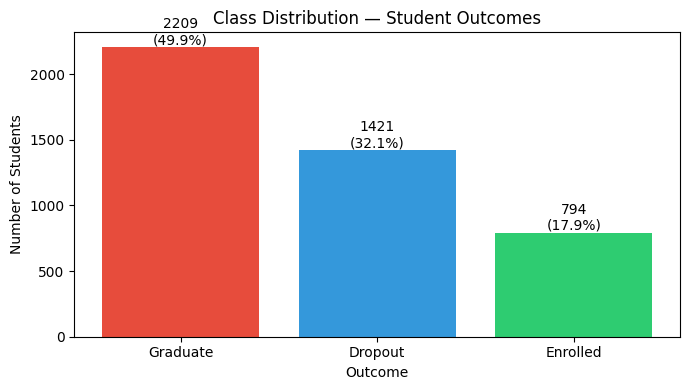

In [11]:
import matplotlib.pyplot as plt

counts = y['Target'].value_counts() # Modified to specify the 'Target' column
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['#E74C3C','#3498DB','#2ECC71'])
plt.title("Class Distribution — Student Outcomes")
plt.ylabel("Number of Students")
plt.xlabel("Outcome")
for i, (label, val) in enumerate(counts.items()):
    plt.text(i, val + 20, f"{val}\n({val/len(y)*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

In [13]:
df = X.copy()
df['Target'] = y['Target'].values

print("Dropout rate by Marital Status:")
print(
    df.groupby('Marital Status')['Target'].apply(lambda x: (x == 'Dropout').mean()).round(3).sort_values(ascending= False)
)

Dropout rate by Marital Status:
Marital Status
6    0.667
2    0.472
4    0.462
5    0.440
1    0.302
3    0.250
Name: Target, dtype: float64


In [14]:
# Coefficient of variation = std/mean, tells you relative spread
cv = (X.std() / X.mean()).abs().sort_values(ascending=False)
print("Top 10 most variable features (relative):")
print(cv.head(10).round(3))
print("\nBottom 10 least variable features:")
print(cv.tail(10).round(3))

Top 10 most variable features (relative):
GDP                                               1152.950
Educational special needs                            9.261
International                                        6.263
Curricular units 1st sem (without evaluations)       5.019
Curricular units 2nd sem (without evaluations)       5.015
Nacionality                                          3.691
Curricular units 2nd sem (credited)                  3.541
Curricular units 1st sem (credited)                  3.325
Debtor                                               2.792
Mother's occupation                                  2.410
dtype: float64

Bottom 10 least variable features:
Curricular units 1st sem (grade)       0.455
Curricular units 1st sem (enrolled)    0.396
Tuition fees up to date                0.368
Curricular units 2nd sem (enrolled)    0.352
Daytime/evening attendance             0.350
Age at enrollment                      0.326
Course                                 0.233
Un

In [15]:
summary = pd.DataFrame({
    'min':  X.min(),
    'max':  X.max(),
    'mean': X.mean().round(2),
    'std':  X.std().round(2),
    'range': (X.max() - X.min()).round(2)
}).sort_values('range', ascending=False)

print(summary.to_string())

                                                  min          max     mean      std    range
Course                                          33.00  9991.000000  8856.64  2063.57  9958.00
Father's occupation                              0.00   195.000000    11.03    25.26   195.00
Mother's occupation                              0.00   194.000000    10.96    26.42   194.00
Nacionality                                      1.00   109.000000     1.87     6.91   108.00
Admission grade                                 95.00   190.000000   126.98    14.48    95.00
Previous qualification (grade)                  95.00   190.000000   132.61    13.19    95.00
Application mode                                 1.00    57.000000    18.67    17.48    56.00
Age at enrollment                               17.00    70.000000    23.27     7.59    53.00
Curricular units 1st sem (evaluations)           0.00    45.000000     8.30     4.18    45.00
Father's qualification                           1.00    44.